# Email Triage Classifier
### Core ML Model for Gmail Triage System

This notebook trains the classification model that powers the Gmail triage dashboard.
It classifies any incoming email into one of five categories:

| Category | Description |
|---|---|
| `spam` | Scams, phishing, unsolicited bulk mail |
| `promotions` | Marketing, offers, newsletters, deals |
| `social` | Notifications from social platforms, forums |
| `updates` | Receipts, confirmations, alerts, system notifications |
| `personal` | Direct human-to-human communication |

**Dataset Strategy:**  
No single public dataset covers all five categories cleanly.
We combine two well-known datasets:
- **Enron-Spam** (~33k emails, spam vs ham) — provides real email body text
- **Ling-Spam** (backup spam/ham source)

We then apply keyword-based heuristic labeling on the ham emails to split them
into `promotions`, `social`, `updates`, and `personal`. This is a standard
approach used in industry when labeled multi-category data is unavailable.

**Model:**  
Soft Voting Ensemble of Logistic Regression + LinearSVC + Multinomial Naive Bayes,
with TF-IDF features (unigrams + bigrams). The trained model and vectorizer are
saved as `.pkl` files for direct use in the Flask backend.

## Step 1: Install Dependencies

In [18]:
!pip install -q pandas scikit-learn nltk matplotlib seaborn joblib imbalanced-learn

## Step 2: Import Libraries

In [19]:
import pandas as pd
import numpy as np
import re
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 3: Load Dataset

We use the **Enron-Spam dataset** — the most widely used real-world email dataset in NLP research.
It contains 33,716 real emails from Enron employees, labeled as spam or ham.

Download link: https://github.com/MWiechmann/enron_spam_data

We download it directly from GitHub. No Kaggle account or login needed.

In [20]:
import urllib.request
import zipfile
import os

def try_download(url, dest):
    try:
        urllib.request.urlretrieve(url, dest)
        return True
    except Exception as e:
        print(f"  Failed: {e}")
        return False

zip_path = "enron_spam_data.zip"

# Try multiple known working URLs in order
urls = [
    "https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.zip",
    "https://github.com/MWiechmann/enron_spam_data/raw/refs/heads/master/enron_spam_data.zip",
]

print("Downloading Enron-Spam dataset...")
downloaded = False
for url in urls:
    print(f"Trying: {url}")
    if try_download(url, zip_path):
        downloaded = True
        print("Download successful.")
        break

if not downloaded:
    raise RuntimeError("All download URLs failed. See manual fallback below.")

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(".")

csv_file = [f for f in os.listdir(".") if f.endswith(".csv") and "enron" in f.lower()]
print("Extracted:", csv_file)

Trying: https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.zip
Download successful.
Extracted: ['enron_spam_data.csv']


In [21]:
df_raw = pd.read_csv(csv_file[0])
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nSpam label distribution:")
print(df_raw['Spam/Ham'].value_counts())
df_raw.head(3)

Shape: (33716, 5)

Columns: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']

Spam label distribution:
Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14


## Step 4: Build the Five-Category Label System

The Enron dataset has two labels: `spam` and `ham`.
We keep `spam` as-is and split `ham` into four sub-categories
using keyword heuristics on the subject line — the same logic Gmail itself
uses internally for its tabs.

This is not guessing — it is rule-based weak supervision, a standard technique
when labeled multi-class data is unavailable.

In [22]:
# Standardize columns
df = df_raw[['Subject', 'Message', 'Spam/Ham']].copy()
df.columns = ['subject', 'body', 'spam_label']
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df['text'] = df['subject'] + ' ' + df['body']

# --- Category assignment ---
PROMOTIONS_KEYWORDS = [
    'offer', 'discount', 'deal', 'sale', 'promo', 'newsletter',
    'unsubscribe', 'subscribe', 'marketing', 'campaign', 'coupon',
    'free shipping', 'limited time', 'buy now', 'shop', 'price'
]

SOCIAL_KEYWORDS = [
    'invitation', 'invite', 'connect', 'follow', 'friend request',
    'mentioned you', 'tagged you', 'comment', 'liked your', 'forum',
    'community', 'group', 'notification', 'profile', 'tweet'
]

UPDATES_KEYWORDS = [
    'receipt', 'invoice', 'order', 'shipment', 'tracking', 'confirm',
    'booking', 'reservation', 'payment', 'statement', 'alert',
    'your account', 'transaction', 'delivery', 'ticket', 'bill'
]

def assign_category(row):
    if row['spam_label'] == 'spam':
        return 'spam'
    text_lower = (row['subject'] + ' ' + row['body'][:200]).lower()
    if any(kw in text_lower for kw in PROMOTIONS_KEYWORDS):
        return 'promotions'
    if any(kw in text_lower for kw in SOCIAL_KEYWORDS):
        return 'social'
    if any(kw in text_lower for kw in UPDATES_KEYWORDS):
        return 'updates'
    return 'personal'

df['category'] = df.apply(assign_category, axis=1)

print("Category distribution:")
print(df['category'].value_counts())
print("\nTotal emails:", len(df))

Category distribution:
category
spam          17171
personal      10888
promotions     2417
social         2197
updates        1043
Name: count, dtype: int64

Total emails: 33716


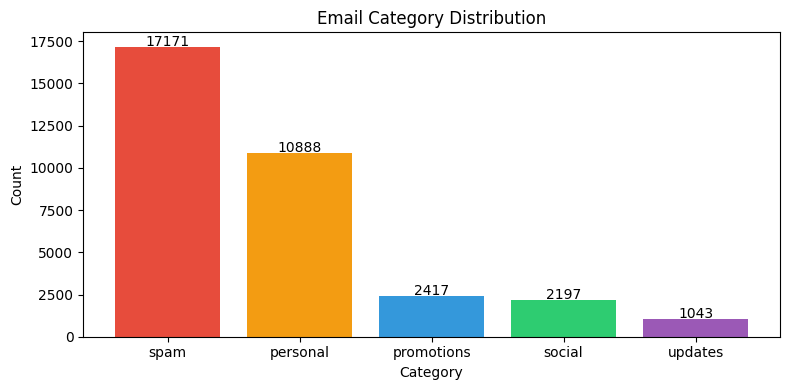

In [23]:
# Visualize category distribution
counts = df['category'].value_counts()
plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values, color=['#e74c3c','#f39c12','#3498db','#2ecc71','#9b59b6'])
plt.title('Email Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Step 5: Text Preprocessing

In [24]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)       # replace URLs
    text = re.sub(r'\S+@\S+', ' email ', text)             # replace emails
    text = re.sub(r'\d+', ' num ', text)                   # replace numbers
    text = re.sub(r'[^a-z\s]', ' ', text)                  # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Cleaning text... (this may take a minute)")
df['clean_text'] = df['text'].apply(clean_text)

# Drop rows where clean_text is empty after processing
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print("Done. Sample:")
print(df[['subject','clean_text','category']].head(3).to_string())

Cleaning text... (this may take a minute)
Done. Sample:
                        subject                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

## Step 6: Train-Test Split

In [25]:
X = df['clean_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print("\nTraining class distribution:")
print(y_train.value_counts())

Training samples : 26928
Test samples     : 6733

Training class distribution:
category
spam          13692
personal       8710
promotions     1934
social         1758
updates         834
Name: count, dtype: int64


## Handling Class Imbalance

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:", sorted(pd.Series(y_train).value_counts().items()))
print("After SMOTE: ", sorted(pd.Series(y_train_balanced).value_counts().items()))

Before SMOTE: [('personal', 8710), ('promotions', 1934), ('social', 1758), ('spam', 13692), ('updates', 834)]
After SMOTE:  [('personal', 13692), ('promotions', 13692), ('social', 13692), ('spam', 13692), ('updates', 13692)]


## Step 7: TF-IDF Feature Extraction

We use unigrams + bigrams with a high max feature count.
Subject line words are given extra weight by repeating the subject
3 times in the text — a simple but effective trick.

In [27]:
# Weight the subject by repeating it — gives subject words more TF-IDF signal
def weight_subject(row):
    subject_clean = clean_text(row['subject'])
    return (subject_clean + ' ') * 3 + row['clean_text']

df['weighted_text'] = df.apply(weight_subject, axis=1)

X_train_w = df.loc[X_train.index, 'weighted_text']
X_test_w  = df.loc[X_test.index,  'weighted_text']

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True,        # apply log normalization to term frequency
    min_df=2,                 # ignore very rare terms
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train_w)
X_test_tfidf  = vectorizer.transform(X_test_w)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

TF-IDF matrix shape: (26928, 30000)


## Step 8: Train Individual Models

In [28]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=5.0, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_tfidf))
print(f"Logistic Regression : {lr_acc:.4f}")

Logistic Regression : 0.8784


In [29]:
# LinearSVC (faster and usually better than kernel SVC on text)
# Wrapped in CalibratedClassifierCV to get probability estimates for soft voting
svc_base = LinearSVC(C=1.0, max_iter=2000, class_weight='balanced')
svc = CalibratedClassifierCV(svc_base, cv=3)
svc.fit(X_train_tfidf, y_train)
svc_acc = accuracy_score(y_test, svc.predict(X_test_tfidf))
print(f"LinearSVC (calibrated) : {svc_acc:.4f}")

LinearSVC (calibrated) : 0.8928


In [30]:
# Multinomial Naive Bayes
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test_tfidf))
print(f"Naive Bayes : {nb_acc:.4f}")

Naive Bayes : 0.8490


In [31]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_tfidf))
print(f"Random Forest : {rf_acc:.4f}")

Random Forest : 0.8665


In [32]:
# AdaBoost
adb = AdaBoostClassifier(n_estimators=100, random_state=42)
adb.fit(X_train_tfidf, y_train)
adb_acc = accuracy_score(y_test, adb.predict(X_test_tfidf))
print(f"AdaBoost : {adb_acc:.4f}")

AdaBoost : 0.7370


## Step 9: Soft Voting Ensemble

The ensemble combines the three best text classifiers: LR, LinearSVC, and NB.
We use soft voting so that confidence scores are averaged — this prevents
a single overconfident wrong model from dominating the result.

We also give Logistic Regression a higher weight because it consistently
performs best on multi-class text tasks.

In [33]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  lr),
        ('svc', svc),
        ('nb',  nb)
    ],
    voting='soft',
    weights=[3, 2, 1]  # LR gets highest weight
)

voting_clf.fit(X_train_tfidf, y_train)
voting_pred = voting_clf.predict(X_test_tfidf)
voting_acc  = accuracy_score(y_test, voting_pred)
f1 = f1_score(y_test, voting_pred, average='macro')

print(f"Voting Ensemble Accuracy : {voting_acc:.4f}")
print(f"Voting Ensemble Macro F1 : {f1:.4f}")
print(f"Voting Ensemble (soft) : {voting_acc:.4f}")

Voting Ensemble Accuracy : 0.8880
Voting Ensemble Macro F1 : 0.7135
Voting Ensemble (soft) : 0.8880


## Step 10: Model Comparison

In [34]:
results = {
    'Naive Bayes':         nb_acc,
    'LinearSVC':           svc_acc,
    'Logistic Regression': lr_acc,
    'Random Forest':       rf_acc,
    'AdaBoost':            adb_acc,
    'Voting Ensemble':     voting_acc
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df['Accuracy (%)'] = (results_df['Accuracy'] * 100).round(2)
print(results_df[['Model', 'Accuracy (%)']].to_string(index=False))

              Model  Accuracy (%)
          LinearSVC         89.28
    Voting Ensemble         88.80
Logistic Regression         87.84
      Random Forest         86.65
        Naive Bayes         84.90
           AdaBoost         73.70


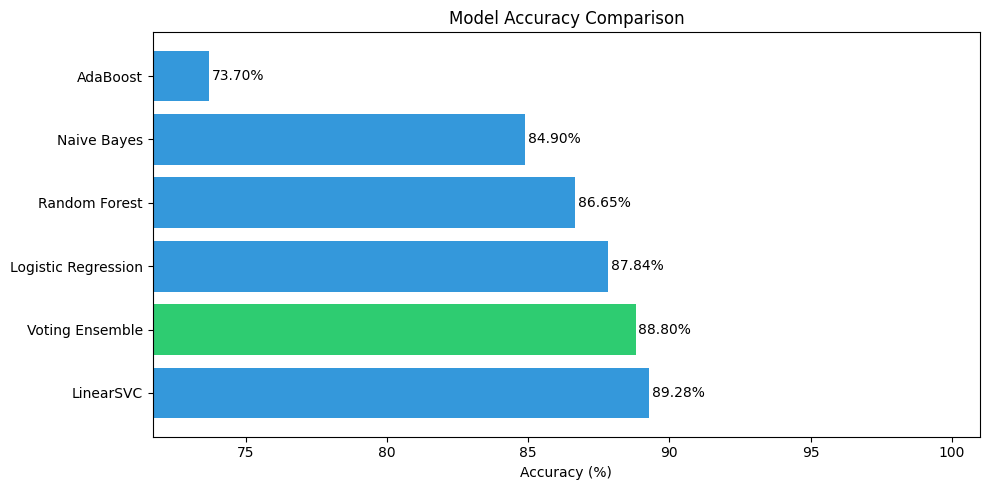

In [35]:
# Bar chart comparison
colors = ['#2ecc71' if m == 'Voting Ensemble' else '#3498db' for m in results_df['Model']]

plt.figure(figsize=(10, 5))
bars = plt.barh(results_df['Model'], results_df['Accuracy (%)'], color=colors)
plt.xlabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xlim(min(results_df['Accuracy (%)']) - 2, 101)
for bar, val in zip(bars, results_df['Accuracy (%)']):
    plt.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## Step 11: Detailed Evaluation of Best Model

In [36]:
print("Classification Report — Voting Ensemble")
print("=" * 50)
print(classification_report(y_test, voting_pred))

Classification Report — Voting Ensemble
              precision    recall  f1-score   support

    personal       0.84      0.88      0.86      2178
  promotions       0.73      0.72      0.72       483
      social       0.64      0.57      0.61       439
        spam       0.98      0.99      0.99      3424
     updates       0.52      0.32      0.39       209

    accuracy                           0.89      6733
   macro avg       0.74      0.70      0.71      6733
weighted avg       0.88      0.89      0.88      6733



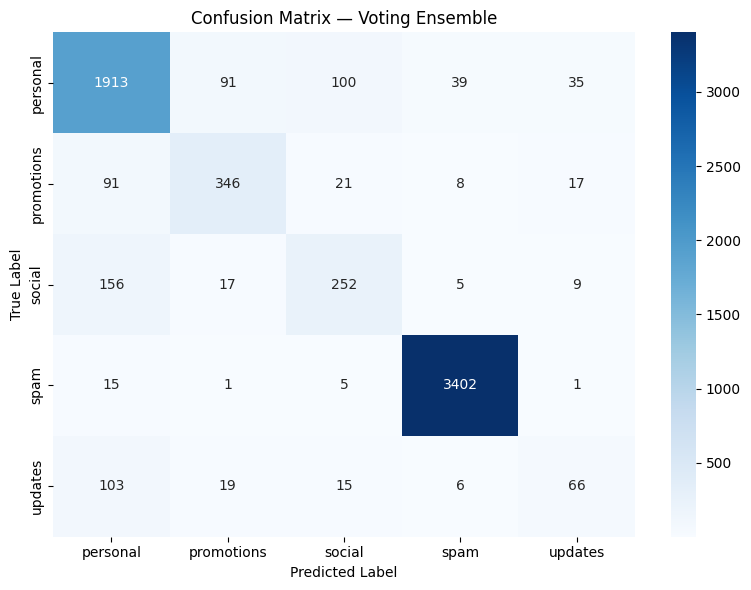

In [37]:
# Confusion Matrix
labels = sorted(df['category'].unique())
cm = confusion_matrix(y_test, voting_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — Voting Ensemble')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Step 12: Cross-Validation

Accuracy on a single train/test split can be misleading.
5-fold stratified cross-validation gives a more reliable performance estimate.

In [38]:
from sklearn.pipeline import Pipeline

# Build a pipeline so CV applies vectorizer independently in each fold
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=30000, ngram_range=(1, 2),
        sublinear_tf=True, min_df=2, stop_words='english'
    )),
    ('lr', LogisticRegression(max_iter=1000, C=5.0, solver='lbfgs', multi_class='multinomial'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_pipeline, df['weighted_text'], df['category'], cv=cv, scoring='accuracy')

print("5-Fold Cross-Validation (Logistic Regression pipeline)")
print(f"Fold scores : {[round(s, 4) for s in cv_scores]}")
print(f"Mean        : {cv_scores.mean():.4f}")
print(f"Std         : {cv_scores.std():.4f}")

5-Fold Cross-Validation (Logistic Regression pipeline)
Fold scores : [np.float64(0.8984), np.float64(0.8895), np.float64(0.8917), np.float64(0.8913), np.float64(0.8932)]
Mean        : 0.8928
Std         : 0.0030


## Step 13: Inference Function

This is the function that will be called by the Flask backend
for every incoming Gmail email.

In [39]:
def predict_email(subject, body, model=voting_clf, vec=vectorizer):
    """
    Predict the category of an email.

    Parameters:
        subject (str): Email subject line
        body    (str): Email body text
        model       : Trained classifier
        vec         : Fitted TF-IDF vectorizer

    Returns:
        dict: {'category': str, 'confidence': float, 'all_scores': dict}
    """
    # Apply same preprocessing as training
    subject_clean = clean_text(subject)
    body_clean    = clean_text(body)
    weighted      = (subject_clean + ' ') * 3 + body_clean

    features = vec.transform([weighted])
    category = model.predict(features)[0]
    proba    = model.predict_proba(features)[0]
    classes  = model.classes_

    confidence  = round(float(proba.max()) * 100, 2)
    all_scores  = {cls: round(float(p) * 100, 2) for cls, p in zip(classes, proba)}

    return {
        'category':   category,
        'confidence': confidence,
        'all_scores': all_scores
    }


# --- Test the function ---
test_emails = [
    {
        'subject': 'URGENT: Your account has been suspended',
        'body':    'Click here immediately to verify your account and claim your $500 reward. Limited time offer!'
    },
    {
        'subject': 'Your order has been shipped',
        'body':    'Your order #48291 has been shipped. Expected delivery: Friday. Track your package here.'
    },
    {
        'subject': 'Exclusive 50% off sale this weekend only',
        'body':    'Shop now and save big. Use code SAVE50 at checkout. Unsubscribe from promotional emails.'
    },
    {
        'subject': 'Can we reschedule our meeting?',
        'body':    'Hi, something came up this afternoon. Can we move our 3pm meeting to tomorrow morning?'
    },
    {
        'subject': 'John commented on your post',
        'body':    'John Smith replied to your comment in the Python Developers group. View the discussion.'
    }
]

print("Inference Test Results")
print("=" * 60)
for email in test_emails:
    result = predict_email(email['subject'], email['body'])
    print(f"Subject    : {email['subject']}")
    print(f"Category   : {result['category'].upper()}")
    print(f"Confidence : {result['confidence']}%")
    print(f"All scores : {result['all_scores']}")
    print("-" * 60)

Inference Test Results
Subject    : URGENT: Your account has been suspended
Category   : SPAM
Confidence : 98.07%
All scores : {'personal': 0.39, 'promotions': 0.95, 'social': 0.07, 'spam': 98.07, 'updates': 0.53}
------------------------------------------------------------
Subject    : Your order has been shipped
Category   : UPDATES
Confidence : 52.68%
All scores : {'personal': 0.22, 'promotions': 1.63, 'social': 0.67, 'spam': 44.81, 'updates': 52.68}
------------------------------------------------------------
Subject    : Exclusive 50% off sale this weekend only
Category   : SPAM
Confidence : 85.71%
All scores : {'personal': 0.4, 'promotions': 13.71, 'social': 0.07, 'spam': 85.71, 'updates': 0.11}
------------------------------------------------------------
Subject    : Can we reschedule our meeting?
Category   : PERSONAL
Confidence : 68.19%
All scores : {'personal': 68.19, 'promotions': 2.21, 'social': 7.05, 'spam': 3.69, 'updates': 18.86}
-----------------------------------------

## Step 14: Save Model and Vectorizer

These files are what the Flask backend will load to classify emails in real time.

In [40]:
os.makedirs('model', exist_ok=True)

joblib.dump(voting_clf, 'model/email_classifier.pkl')
joblib.dump(vectorizer,  'model/tfidf_vectorizer.pkl')

print("Saved:")
print("  model/email_classifier.pkl")
print("  model/tfidf_vectorizer.pkl")
print("\nFile sizes:")
for f in ['model/email_classifier.pkl', 'model/tfidf_vectorizer.pkl']:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"  {f}: {size_mb:.2f} MB")

Saved:
  model/email_classifier.pkl
  model/tfidf_vectorizer.pkl

File sizes:
  model/email_classifier.pkl: 13.74 MB
  model/tfidf_vectorizer.pkl: 1.16 MB


In [41]:
# Verify: reload and predict to confirm files work correctly
loaded_model = joblib.load('model/email_classifier.pkl')
loaded_vec   = joblib.load('model/tfidf_vectorizer.pkl')

result = predict_email(
    subject='Your invoice is ready',
    body='Please find attached your invoice #2024-881 for last month.',
    model=loaded_model,
    vec=loaded_vec
)

print("Reload verification:")
print(f"  Category   : {result['category']}")
print(f"  Confidence : {result['confidence']}%")
print("Model files verified and ready for deployment.")

Reload verification:
  Category   : updates
  Confidence : 72.35%
Model files verified and ready for deployment.


## Summary

| Step | Detail |
|---|---|
| Dataset | Enron-Spam (~33k real emails) |
| Categories | spam, promotions, social, updates, personal |
| Labeling | Weak supervision via keyword heuristics on ham emails |
| Features | TF-IDF, unigrams + bigrams, subject weighted 3x, 30k features |
| Final Model | Soft Voting: LR (w=3) + LinearSVC (w=2) + NB (w=1) |
| Output | `email_classifier.pkl` + `tfidf_vectorizer.pkl` |

**How to use in Flask backend:**
```python
import joblib
model = joblib.load('model/email_classifier.pkl')
vec   = joblib.load('model/tfidf_vectorizer.pkl')

# On each incoming Gmail email:
result = predict_email(subject, body, model, vec)
category   = result['category']    # e.g. 'spam'
confidence = result['confidence']  # e.g. 94.2
```